# Numerical Integration: Left, Right, Midpoint, and Trapezoid Rules

## Overview
Numerical integration approximates the definite integral  


$
\int_a^b f(x)\,dx
$


by summing areas of simple geometric shapes. The four core CLEP-level methods are:

---

## **1. Left Riemann Sum**
Uses the **left endpoint** of each subinterval.



$
L_n = \Delta x \left[f(x_0) + f(x_1) + \cdots + f(x_{n-1})\right]
$



- **Underestimates** when $f$ is increasing  
- **Overestimates** when $f$ is decreasing  

---

## **2. Right Riemann Sum**
Uses the **right endpoint** of each subinterval.



$
R_n = \Delta x \left[f(x_1) + f(x_2) + \cdots + f(x_n)\right]
$



- Opposite bias of the Left Sum  

---

## **3. Midpoint Rule**
Uses the **midpoint** of each subinterval.



$
M_n = \Delta x \left[f(m_1) + f(m_2) + \cdots + f(m_n)\right]
$



- Often **more accurate** than Left/Right  
- Midpoints tend to “average out” curvature  

---

## **4. Trapezoid Rule**
Approximates each slice with a **trapezoid** instead of a rectangle.



$
T_n = \frac{\Delta x}{2}\left[f(x_0) + 2f(x_1) + \cdots + 2f(x_{n-1}) + f(x_n)\right]
$



- Equivalent to averaging Left and Right sums:


$
T_n = \frac{L_n + R_n}{2}
$


- **Overestimates** when concave up  
- **Underestimates** when concave down  

---

## Key Relationships
- $T_n = \frac{L_n + R_n}{2}$
- Midpoint is usually the most accurate for the same $n$
- All methods converge to the true integral as $n \to \infty$

---


## Curvature and Estimation Behavior

- **Left sum**  
  - Overestimates when $f$ is decreasing  
  - Underestimates when $f$ is increasing  

- **Right sum**  
  - Overestimates when $f$ is increasing  
  - Underestimates when $f$ is decreasing  

- **Midpoint rule**  
  - Overestimates when $f$ is concave down  
  - Underestimates when $f$ is concave up  

- **Trapezoid rule**  
  - Overestimates when $f$ is concave up  
  - Underestimates when $f$ is concave down  

**Key curvature rule:**  
Concave up → Trapezoid too big, Midpoint too small  
Concave down → Trapezoid too small, Midpoint too big


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Example function: concave up
def f(x):
    return x**2 + 1

a, b = 0, 3
n = 6
x = np.linspace(a, b, n + 1)
dx = (b - a) / n

x, dx


(array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. ]), 0.5)

In [23]:
# Left Riemann sum
L = np.sum(f(x[:-1])) * dx

# Right Riemann sum
R = np.sum(f(x[1:])) * dx

# Midpoint rule
midpoints = (x[:-1] + x[1:]) / 2
M = np.sum(f(midpoints)) * dx

# Trapezoid rule
T = 0.5 * (L + R)

L, R, M, T


(np.float64(9.875),
 np.float64(14.375),
 np.float64(11.9375),
 np.float64(12.125))

In [24]:
# True integral for f(x) = x^2 + 1 on [a,b]
true_value = (b**3)/3 + b - ((a**3)/3 + a)

true_value, L, R, M, T


(12.0,
 np.float64(9.875),
 np.float64(14.375),
 np.float64(11.9375),
 np.float64(12.125))

## Visualization of All Four Methods



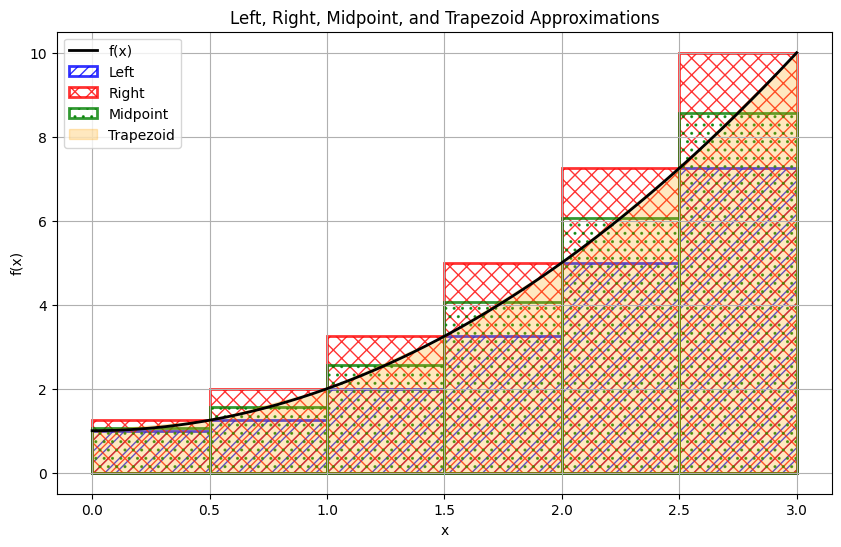

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

xx = np.linspace(a, b, 400)
ax.plot(xx, f(xx), 'k', linewidth=2, label='f(x)')

# Left rectangles (blue, diagonal hatch)
for i in range(n):
    ax.add_patch(
        plt.Rectangle(
            (x[i], 0),
            dx,
            f(x[i]),
            edgecolor='blue',
            facecolor='none',
            hatch='///',
            linewidth=2,
            alpha=0.8,
            label='Left' if i == 0 else None
        )
    )

# Right rectangles (red, cross hatch)
for i in range(n):
    ax.add_patch(
        plt.Rectangle(
            (x[i], 0),
            dx,
            f(x[i+1]),
            edgecolor='red',
            facecolor='none',
            hatch='xx',
            linewidth=2,
            alpha=0.8,
            label='Right' if i == 0 else None
        )
    )

# Midpoint rectangles (green, dotted hatch)
for i in range(n):
    ax.add_patch(
        plt.Rectangle(
            (x[i], 0),
            dx,
            f(midpoints[i]),
            edgecolor='green',
            facecolor='none',
            hatch='..',
            linewidth=2,
            alpha=0.8,
            label='Midpoint' if i == 0 else None
        )
    )

# Trapezoids (orange fill, no hatch)
for i in range(n):
    xs = [x[i], x[i+1]]
    ys = [f(x[i]), f(x[i+1])]
    ax.fill_between(
        xs,
        ys,
        color='orange',
        alpha=0.25,
        label='Trapezoid' if i == 0 else None
    )

ax.set_title("Left, Right, Midpoint, and Trapezoid Approximations")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.grid(True)
ax.legend(loc='upper left')

plt.show()


Text(0.5, 1.0, 'Decreasing Function: Left, Right, Midpoint, Trapezoid Approximations')

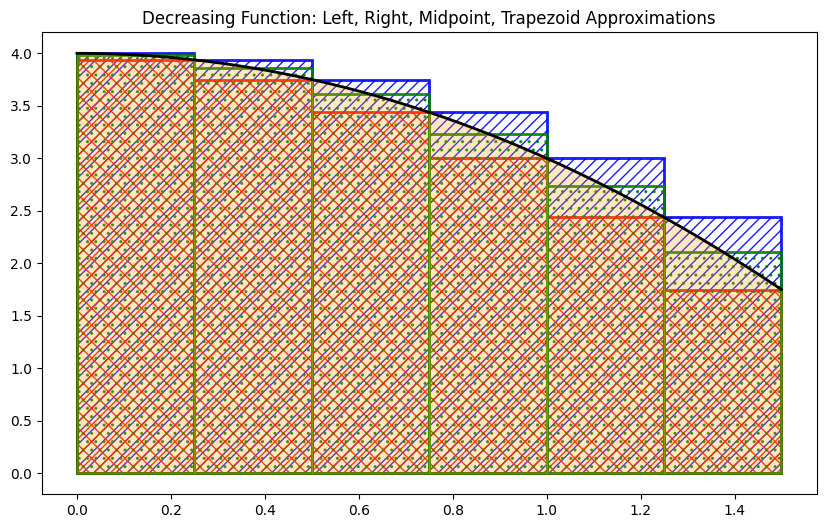

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Decreasing function
def f(x):
    return 4 - x**2   # decreasing on [0, 1.5]

a, b = 0, 1.5
n = 6
x = np.linspace(a, b, n + 1)
dx = (b - a) / n
midpoints = (x[:-1] + x[1:]) / 2

fig, ax = plt.subplots(figsize=(10, 6))

xx = np.linspace(a, b, 400)
ax.plot(xx, f(xx), 'k', linewidth=2, label='f(x)')

# Left rectangles (blue, diagonal hatch)
for i in range(n):
    ax.add_patch(
        plt.Rectangle(
            (x[i], 0),
            dx,
            f(x[i]),
            edgecolor='blue',
            facecolor='none',
            hatch='///',
            linewidth=2,
            alpha=0.9,
            label='Left' if i == 0 else None
        )
    )

# Right rectangles (red, cross hatch)
for i in range(n):
    ax.add_patch(
        plt.Rectangle(
            (x[i], 0),
            dx,
            f(x[i+1]),
            edgecolor='red',
            facecolor='none',
            hatch='xx',
            linewidth=2,
            alpha=0.9,
            label='Right' if i == 0 else None
        )
    )

# Midpoint rectangles (green, dotted hatch)
for i in range(n):
    ax.add_patch(
        plt.Rectangle(
            (x[i], 0),
            dx,
            f(midpoints[i]),
            edgecolor='green',
            facecolor='none',
            hatch='..',
            linewidth=2,
            alpha=0.9,
            label='Midpoint' if i == 0 else None
        )
    )

# Trapezoids (orange fill)
for i in range(n):
    xs = [x[i], x[i+1]]
    ys = [f(x[i]), f(x[i+1])]
    ax.fill_between(
        xs,
        ys,
        color='orange',
        alpha=0.25,
        label='Trapezoid' if i == 0 else None
    )

ax.set_title("Decreasing Function: Left, Right, Midpoint, Trapezoid Approximations")
